<a href="https://colab.research.google.com/github/Samiksha22911/AIML-LAB-EXPERIMENTS/blob/main/Decision_Tree_Classification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Experiment 5: Decision Tree Classification
Dataset: Titanic dataset (real-world, 150-row sample)

- Predicts passenger survival
- Preprocesses: handles missing values, encodes categorical features
- Splits data and evaluates performance
- Visualizes the resulting decision tree
"""

'\nExperiment 5: Decision Tree Classification\nDataset: Titanic dataset (real-world, 150-row sample)\n\n- Predicts passenger survival\n- Preprocesses: handles missing values, encodes categorical features\n- Splits data and evaluates performance\n- Visualizes the resulting decision tree\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [3]:
# 1. Load dataset

df = pd.read_csv("dataset_titanic.csv")
print("Dataset shape:", df.shape)
print(df.isnull().sum())

Dataset shape: (150, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             34
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          116
Embarked         0
dtype: int64


In [4]:
# 2. Preprocessing

# Drop columns that are not useful predictors / too many missing values / free text
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Encode categorical features
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

print("\nAfter preprocessing:")
print(df.head())

X = df.drop(columns=["Survived"])
y = df["Survived"].values


After preprocessing:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  29.5      0      0   7.7333        True       False
1         1       3    0  39.0      0      0   7.9250       False        True
2         0       3    0  28.0      2      0   7.9250       False        True
3         0       3    0  30.0      1      0  16.1000       False        True
4         0       2    0  23.0      0      0  13.0000       False        True


In [5]:
# 3. Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# 4. Train Decision Tree

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [7]:
# 5. Evaluate

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.3f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Died", "Survived"]).plot(cmap="Greens")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.close()

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="seagreen")
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.close()



Accuracy:  0.800
Precision: 0.857
Recall:    0.545
F1-score:  0.667



Saved plots -> confusion_matrix.png, feature_importance.png, decision_tree.png


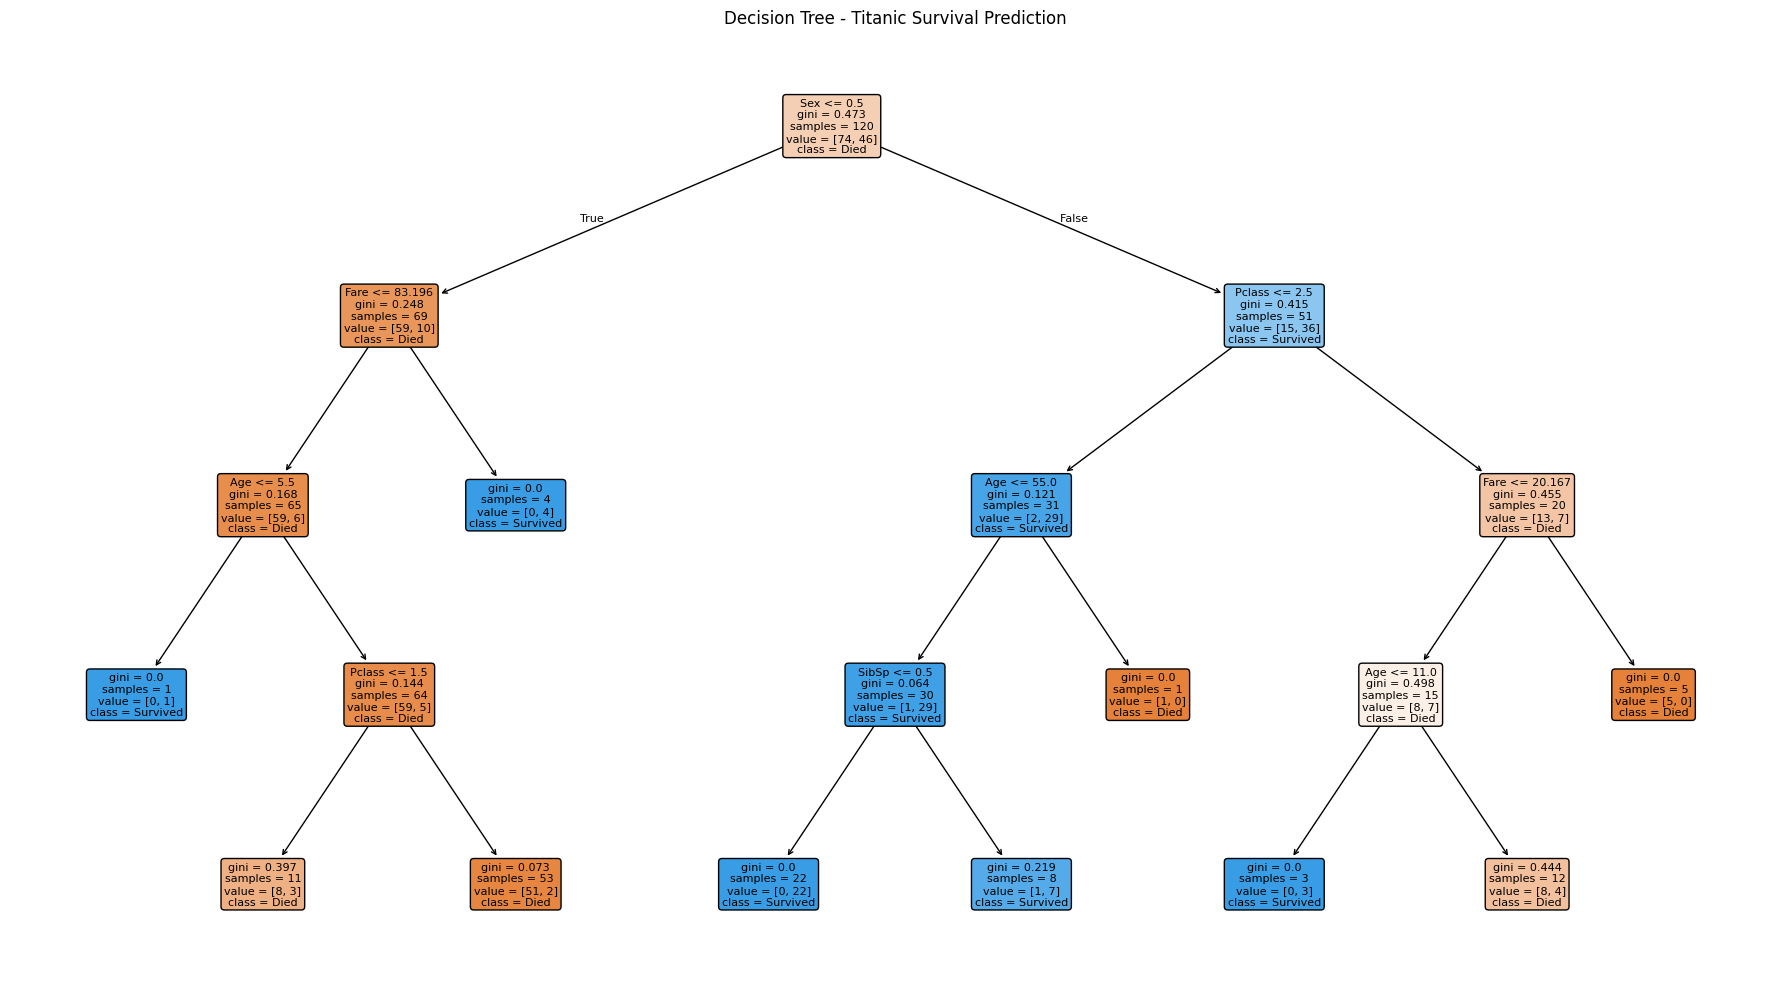

In [8]:
# 6. Visualize the decision tree

plt.figure(figsize=(18, 10))
plot_tree(model, feature_names=X.columns, class_names=["Died", "Survived"],
          filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree - Titanic Survival Prediction")
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150)
print("\nSaved plots -> confusion_matrix.png, feature_importance.png, decision_tree.png")
plt.show()
